# 1) Testing IDyOM Cross Validation 


## Extracting data from the BiMMuDA dataset

In [73]:
# import os
# import shutil

# source_root = "data/BiMMuDA"
# destination = "all_midis"

# os.makedirs(destination, exist_ok=True)

# for root, dirs, files in os.walk(source_root):
#     for file in files:
#         if file.endswith(".mid"):
#             src_path = os.path.join(root, file)
#             dst_path = os.path.join(destination, file)
#             shutil.copy2(src_path, dst_path)

### Clean the files to only include monophonic and non corrupted melody fragments

In [74]:
# import mido

# SOURCE_DIR = "all_midis"
# DEST_DIR = "clean_monophonic_midis"

# os.makedirs(DEST_DIR, exist_ok=True)

# def is_monophonic(midi_path):
#     try:
#         midi = mido.MidiFile(midi_path)
#     except Exception:
#         return False, "corrupted"

#     notes = []
#     current_time = 0

#     for track in midi.tracks:
#         current_time = 0
#         active_notes = {}

#         for msg in track:
#             current_time += msg.time

#             if msg.type == "note_on" and msg.velocity > 0 and msg.channel != 9:
#                 active_notes[msg.note] = current_time

#             elif (msg.type == "note_off") or (msg.type == "note_on" and msg.velocity == 0):
#                 if msg.note in active_notes:
#                     start = active_notes.pop(msg.note)
#                     end = current_time
#                     notes.append((start, end))

#     if len(notes) == 0:
#         return False, "no_notes"

#     # sort by start time
#     notes.sort(key=lambda x: x[0])

#     # check overlap
#     prev_end = notes[0][1]
#     for start, end in notes[1:]:
#         if start < prev_end:
#             return False, "polyphonic"
#         prev_end = max(prev_end, end)

#     return True, "monophonic"


# print("Cleaning MIDI dataset for IDyOM...\n")

# for file in os.listdir(SOURCE_DIR):
#     if file.endswith(".mid"):
        
#         # Skip files containing "full"
#         if "full" in file.lower():
#             print(f"Skipping {file} → contains 'full'")
#             continue
        
#         path = os.path.join(SOURCE_DIR, file)
#         ok, reason = is_monophonic(path)

#         if ok:
#             shutil.copy2(path, os.path.join(DEST_DIR, file))
#         else:
#             print(f"Skipping {file} → {reason}")

# print("\nDone.")

## Run the IDyOM cross validation function on the dataset

In [75]:
# ! python3 IDyOM/App.py -c clean_monophonic_midis/

### Add the resulting pickle file path below to inspect the data

In [76]:
import pickle

with open("out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    data = pickle.load(f)

# print(type(data))

In [77]:
# print(data.keys())

## Convert to pandas dataframe to work with joining data

In [78]:
import pandas as pd

df = pd.DataFrame(data)
df

,2007_05_2,1994_04_1,2005_02_1,2001_05_1,1969_01_2,1991_01_3,1983_05_1,1970_04_2,2013_01_1,1978_04_2,...,1977_03_3,2010_05_3,2020_04_2,2008_01_2,2011_05_2,1969_02_2,2017_03_1,1960_05_2,2001_01_1,info
0,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.04403345931711, 5.442211984259578, 3.253372...","[4.234979496145881, 3.902638628962201, 3.40916...","[4.33746426547517, 4.359463448456414, 3.021119...","[5.013402927647211, 3.6121805299638914, 1.9704...","[3.9987459186963332, 4.820412912904651, 3.2024...","[5.236358275046125, 4.491862103757247, 3.20446...","[5.308482796591717, 5.469910446807136, 4.89387...","[4.033551083680571, 2.741922684381036, 2.55264...","[5.972207613293579, 2.776361677681063, 2.07749...",...,"[5.966815245577175, 4.638600777352498, 3.49517...","[4.1006147590367865, 9.674416303582388, 3.1832...","[3.9833480462958644, 5.573980200011228, 2.2260...","[4.245301634436269, 4.140517732168921, 2.73087...","[4.012807024211956, 4.682613083897336, 5.65416...","[4.740425764518198, 6.905797434282788, 4.47764...","[4.22621731795505, 4.727247856317818, 3.807374...","[4.03614526904113, 4.607840070327161, 2.457493...","[6.808723370532655, 5.451702494704331, 5.54131...",Each variable corresponds to a song. For each ...
1,"[4.73569841252648, 4.959952872069636, 4.207138...","[4.73569841252648, 5.132129147137926, 4.207155...","[4.73569841252648, 4.40031126411454, 4.2057256...","[4.73569841252648, 3.9547598787796634, 4.26529...","[4.73569841252648, 4.098876513457048, 4.231377...","[4.73569841252648, 4.940387869523069, 4.292785...","[4.73569841252648, 4.389229580615364, 4.247225...","[4.73569841252648, 4.751780935110515, 4.300529...","[4.73569841252648, 3.982733272564505, 4.217632...","[4.73569841252648, 4.480421512252237, 4.212455...",...,"[4.725227889482467, 4.631933801741046, 4.24897...","[4.725227889482467, 4.7371844271227115, 4.1198...","[4.725227889482467, 4.7992460108214186, 4.1819...","[4.725227889482467, 4.22123692823236, 4.280765...","[4.725227889482467, 3.5686794844662986, 4.2772...","[4.725227889482467, 4.15677944822524, 4.308557...","[4.731551948168222, 4.627539566834528, 4.23859...","[4.731551948168222, 4.518428159556651, 4.26964...","[4.731551948168222, 4.820671636518481, 4.24551...",Each variable corresponds to a song. For each ...


In [79]:
df = df.drop(columns=["info"])

In [80]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song in df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = df.loc[0, song]
    entropy_vector = df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.406358      3.138299
1   1951        4.781330      3.560367
2   1952        4.461024      3.403464
3   1953        4.960273      3.605045
4   1954        4.255583      3.329353
..   ...             ...           ...
70  2020        3.618874      2.931633
71  2021        3.152493      2.692932
72  2022        3.110473      2.689270
73  2023        3.499404      2.974384
74  2024        3.664309      3.016401

[75 rows x 3 columns]


In [81]:
# yearly_stats.to_csv('out/eval/data/likelihoods_cross-eval_k_fold_5_quantization_24_maxOrder_20_viewpoints_pitch_length.csv', index=False)

## Generate a pandas dataframe for the metadata

In [82]:
import pandas as pd

genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")

# print(genre_df.head())

In [83]:
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)

In [84]:
genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

# genre_subset

In [85]:
# df.transpose()

In [86]:
songs = pd.Series(df.columns[:])  # skip "info" column

song_name_df = pd.DataFrame({
    "song": songs,
    "year_position": songs.str.extract(r"(\d{4}_\d{2})")[0]
})

# song_name_df

In [87]:
df_t = df.T.reset_index()
df_t.columns = ["year_position_raw", "surprisal", "entropy"]
df_t["year_position"] = df_t["year_position_raw"].str.rsplit("_", n=1).str[0]
# df_t

### Merge together metadata and the dataframe containing surprisal and entropy

In [88]:
merged_df = pd.merge(df_t, genre_subset, on="year_position", how= "left")
merged_df.drop(index=merged_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_df
merged_df["mean_surprisal"] = merged_df["surprisal"].apply(np.mean)
merged_df["mean_entropy"] = merged_df["entropy"].apply(np.mean)

merged_df

,year_position_raw,surprisal,entropy,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),mean_surprisal,mean_entropy
0,2007_05_2,"[4.516480270205056, 3.2500684503633095, 4.7882...","[4.73569841252648, 4.959952872069636, 4.207138...",2007_05,R&B,Hip-hop,Snap,NaN,NaN,4.378617,3.517372
1,1994_04_1,"[4.04403345931711, 5.442211984259578, 3.253372...","[4.73569841252648, 5.132129147137926, 4.207155...",1994_04,Pop,NaN,NaN,NaN,NaN,4.880874,3.412200
2,2005_02_1,"[4.234979496145881, 3.902638628962201, 3.40916...","[4.73569841252648, 4.40031126411454, 4.2057256...",2005_02,Hip-hop,NaN,NaN,NaN,NaN,2.838059,2.727959
3,2001_05_1,"[4.33746426547517, 4.359463448456414, 3.021119...","[4.73569841252648, 3.9547598787796634, 4.26529...",2001_05,R&B,Hip-hop,NaN,NaN,NaN,4.112367,2.974622
4,1969_01_2,"[5.013402927647211, 3.6121805299638914, 1.9704...","[4.73569841252648, 4.098876513457048, 4.231377...",1969_01,Pop,NaN,Bubblegum pop,NaN,NaN,2.618158,2.553817
...,...,...,...,...,...,...,...,...,...,...,...
1157,2008_01_2,"[4.245301634436269, 4.140517732168921, 2.73087...","[4.725227889482467, 4.22123692823236, 4.280765...",2008_01,Hip-hop,NaN,Crunk,Pop-rap,NaN,2.632525,2.353040
1158,2011_05_2,"[4.012807024211956, 4.682613083897336, 5.65416...","[4.725227889482467, 3.5686794844662986, 4.2772...",2011_05,EDM/Dance,Hip-hop,Hip house,Pop rap,NaN,2.909164,1.860560
1159,1969_02_2,"[4.740425764518198, 6.905797434282788, 4.47764...","[4.725227889482467, 4.15677944822524, 4.308557...",1969_02,Funk/Soul,NaN,Pyschedelic soul,NaN,NaN,4.961784,3.456743
1160,2017_03_1,"[4.22621731795505, 4.727247856317818, 3.807374...","[4.731551948168222, 4.627539566834528, 4.23859...",2017_03,Funk/Soul,R&B,NaN,NaN,NaN,2.857608,2.645661


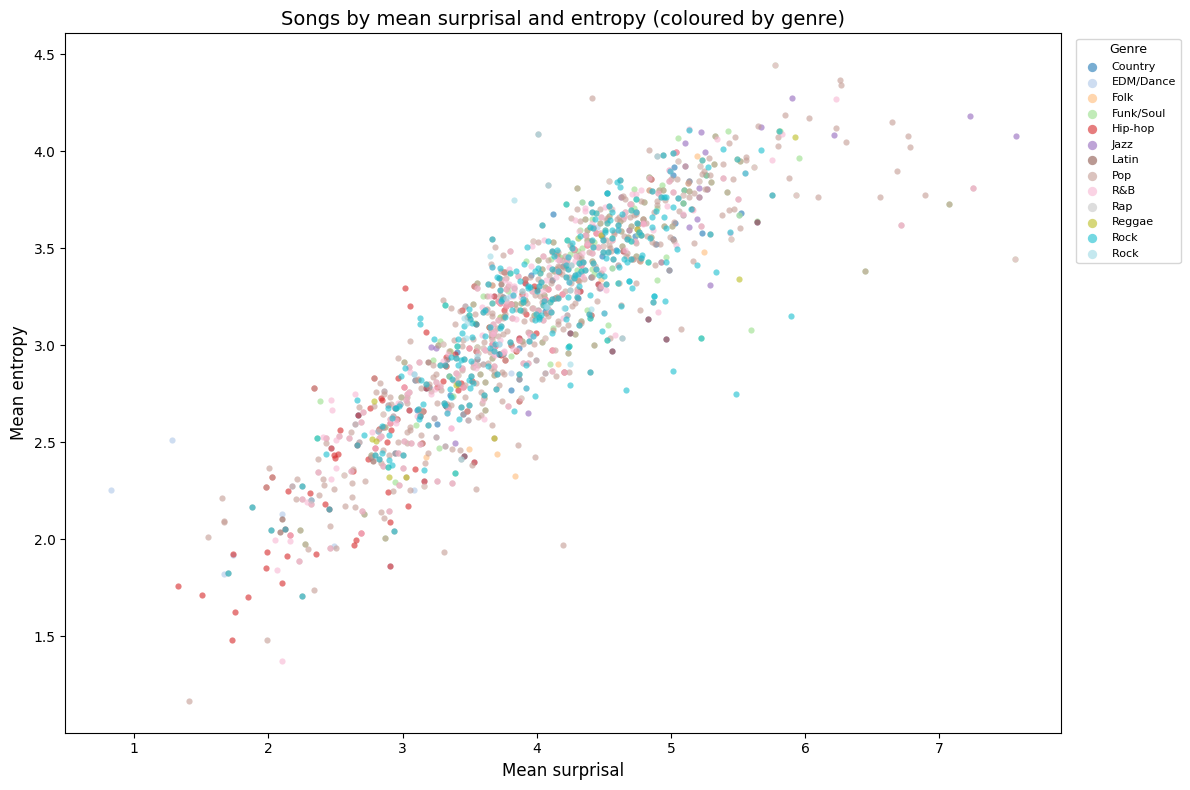

In [89]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = merged_df.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()


In [90]:
# merged_df.to_csv('out/eval/data/merged_data.csv', index=False)

In [91]:
print(merged_df["Genre (Broad 1)"].value_counts())


Genre (Broad 1)
Pop          440
Rock         202
R&B          146
Funk/Soul    143
Hip-hop       82
Country       41
EDM/Dance     28
Rock          22
Folk          18
Jazz          17
Latin         12
Reggae        11
Name: count, dtype: int64


In [92]:
# merged_df[merged_df["Genre (Broad 1)"].isna()]

In [93]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song, group in merged_df.groupby("year_position"):
    year = song[:4]  # extract year from filename

    mean_surprisal = np.mean([val for sublist in group["surprisal"] for val in sublist])
    mean_entropy = np.mean([val for sublist in group["entropy"] for val in sublist])
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

yearly_stats = pd.DataFrame(yearly_stats)

print(yearly_stats)

    year  mean_surprisal  mean_entropy
0   1950        4.407575      3.211373
1   1951        4.771719      3.567203
2   1952        4.407439      3.337397
3   1953        4.937063      3.591413
4   1954        4.226230      3.272265
..   ...             ...           ...
70  2020        3.635916      2.946720
71  2021        3.038605      2.625418
72  2022        3.126063      2.660467
73  2023        3.445590      2.935530
74  2024        3.556795      3.033799

[75 rows x 3 columns]


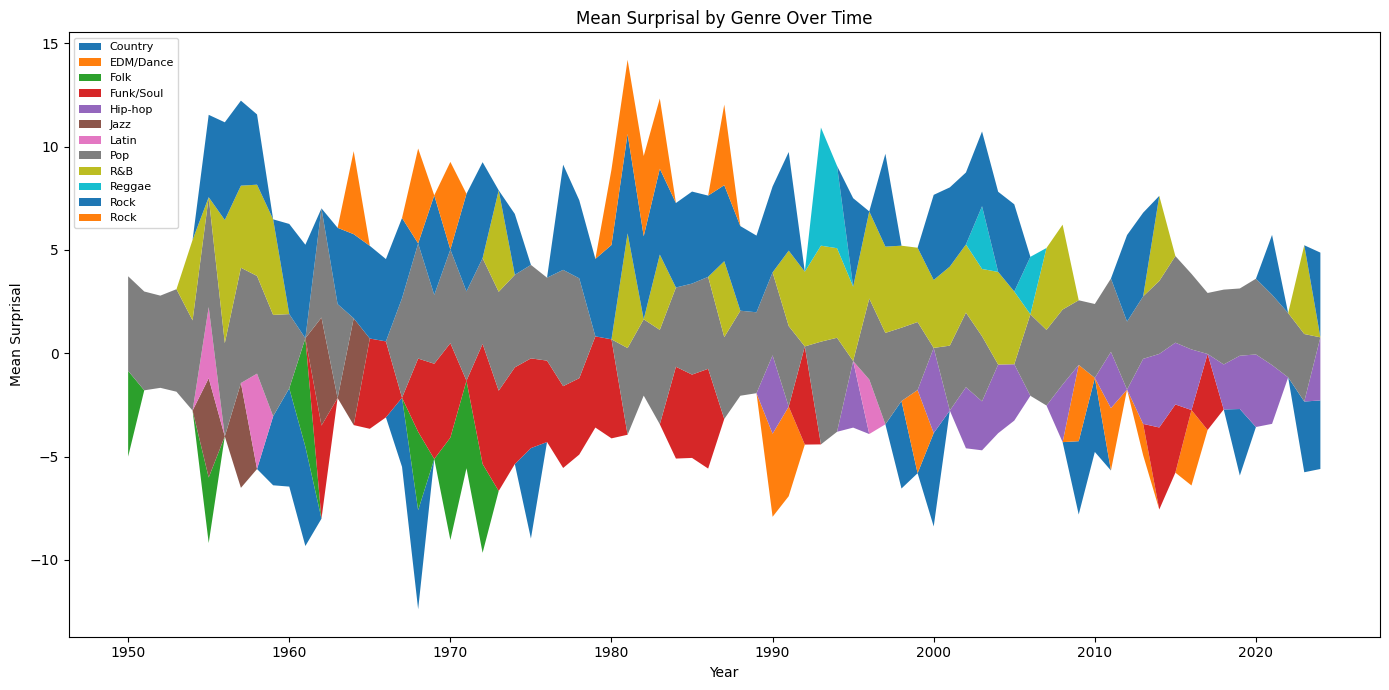

In [94]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Extract year and aggregate by year + genre ---
merged_df["year"] = merged_df["year_position"].str[:4].astype(int)

yearly_genre = (
    merged_df.groupby(["year", "Genre (Broad 1)"])["mean_surprisal"]
    .mean()
    .reset_index()
)

# Pivot so genres are columns, years are rows
pivot_df = yearly_genre.pivot(index="year", columns="Genre (Broad 1)", values="mean_surprisal").fillna(0)

# --- Step 2: Plot streamgraph ---
years = pivot_df.index.values
genres = pivot_df.columns.tolist()
values = pivot_df.values.T  # shape: (n_genres, n_years)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(years, values, labels=genres, baseline="wiggle")  # "wiggle" gives the stream shape

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Mean Surprisal by Genre Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Surprisal")

plt.tight_layout()
plt.show()

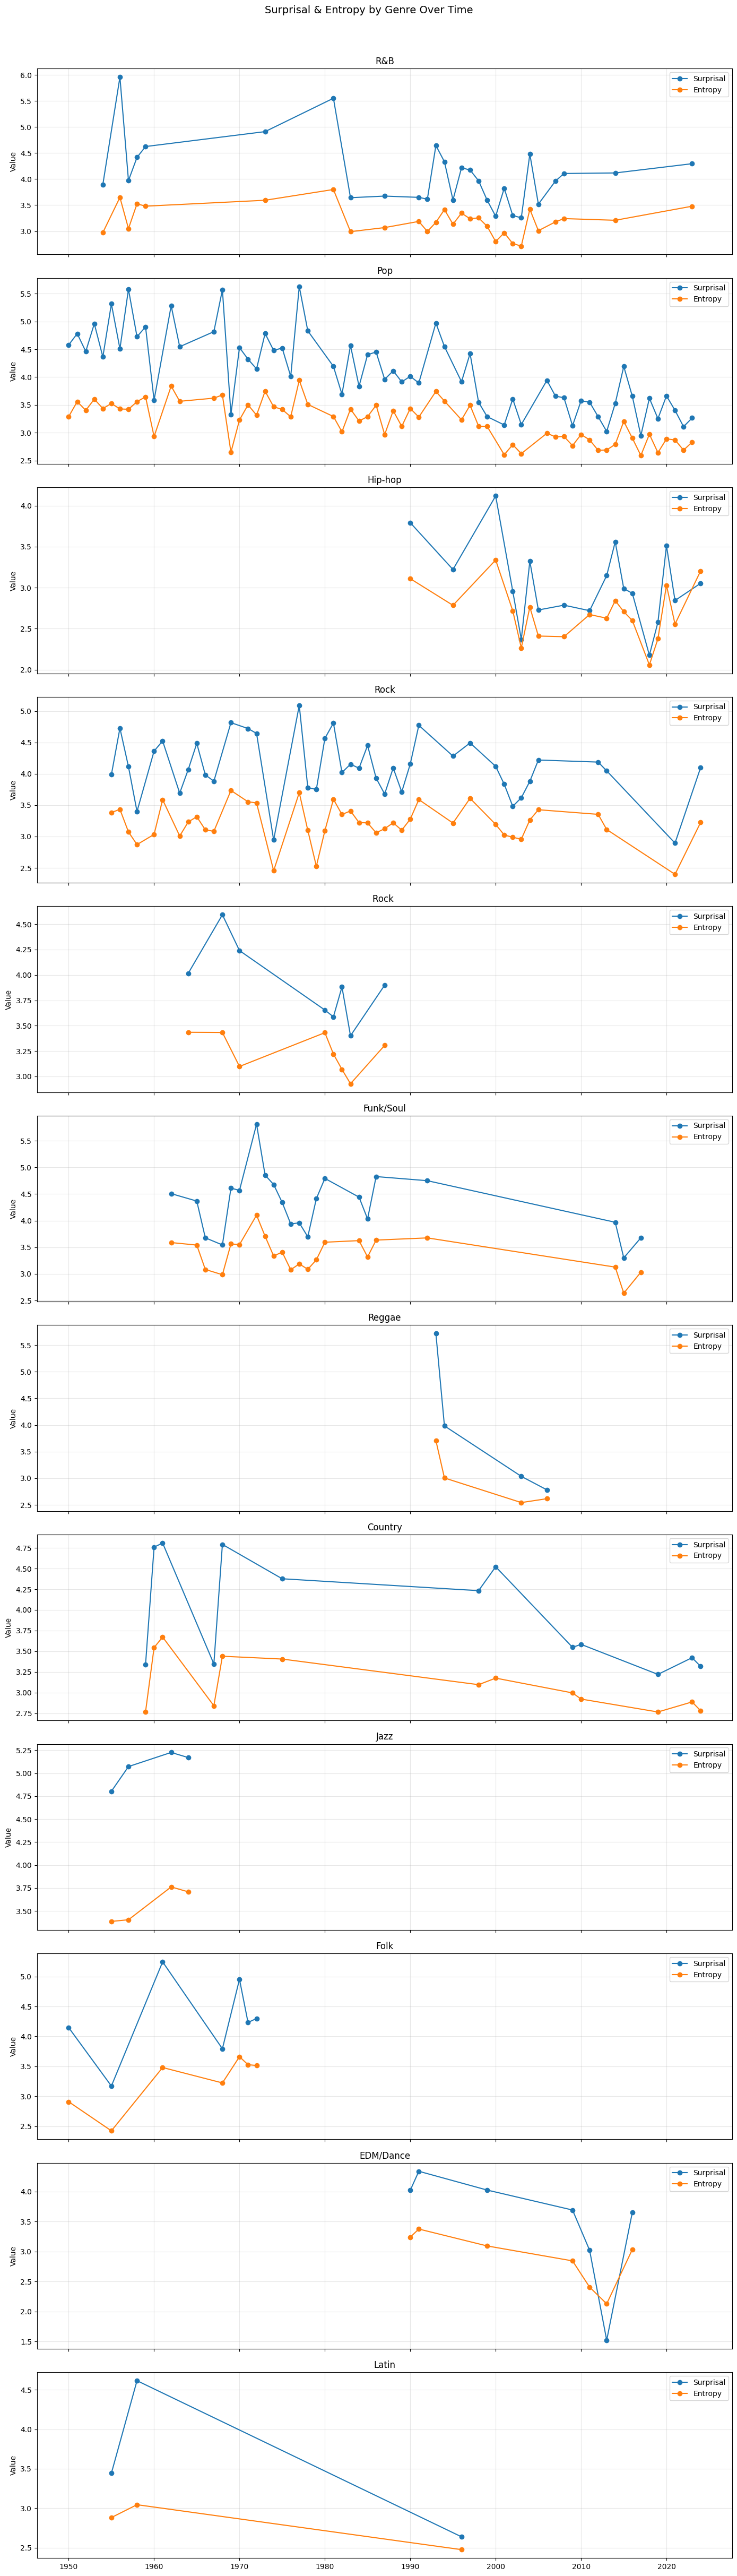

In [95]:
import matplotlib.pyplot as plt

genres = merged_df["Genre (Broad 1)"].dropna().unique()

fig, axes = plt.subplots(len(genres), 1, figsize=(14, 4 * len(genres)), sharex=True)

for ax, genre in zip(axes, genres):
    genre_df = merged_df[merged_df["Genre (Broad 1)"] == genre].copy()
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    ax.set_title(genre)
    ax.set_ylabel("Value")
    # ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("Year")
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## to do: 

- try to get the PIC and RIC values replicated using the python implementation of IDyOM 

# 2) Try incorporating long term memory on the evaluation 

- try testing a genre's perspective on another genre 
- try testing a rolling average to see which decade is more surprised by the other 


### Organize folders of training data

In [96]:
# ! python3 organize_midis_by_5yr.py -i TAR/midis -o tar_midis_by_5yr_window -w 4 -s 1

### Run Surprisal calculation on every year based on the preceeding 5 years

In [97]:
# ! python3 run_eras_idyom.py -d midis_by_5yr_window -r 5yr_window_results

## Explore one example 5 yr lookback file (1951-1955 tested on 1950-1954 training data)

In [98]:
import pickle 
import pandas as pd

with open("out/1951-1955/surprises/1950-1954/data/1950-1954_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle", "rb") as f:
    data = pickle.load(f)
    
df = pd.DataFrame(data)
df = df.drop(columns=["info"])

import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song in df.columns:
    year = int(song[:4])  # extract year from filename
    
    surprisal_vector = df.loc[0, song]
    entropy_vector = df.loc[1, song]
    
    mean_surprisal = np.mean(surprisal_vector)
    mean_entropy = np.mean(entropy_vector)
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

   year  mean_surprisal  mean_entropy
0  1951        1.992225      2.262176
1  1952        1.963116      2.281485
2  1953        2.242342      2.503077
3  1954        1.922081      2.273578
4  1955        4.140432      3.094362


In [99]:
genre_df = pd.read_csv("data/BiMMuDa/metadata/bimmuda_per_song_metadata.csv")
genre_df["year_position"] = (
    genre_df["Year"].astype(str)
    + "_"
    + genre_df["Position"].astype(str).str.extract(r"(\d+)")[0].str.zfill(2)
    + genre_df["Position"].astype(str).str.extract(r"([a-zA-Z]+)")[0].fillna("")
)
genre_subset = genre_df[[
    "year_position",
    "Genre (Broad 1)",
    "Genre (Broad 2)",
    "Genre (Specific 1)",
    "Genre (Specific 2)",
    "Genre (Specific 3)"
]]

In [100]:
df_t = df.T.reset_index()
df_t.columns = ["year_position_raw", "surprisal", "entropy"]
df_t["year_position"] = df_t["year_position_raw"].str.rsplit("_", n=1).str[0]

merged_df = pd.merge(df_t, genre_subset, on="year_position", how= "left")
merged_df.drop(index=merged_df.index[-1],axis=0,inplace=True)

# Compute per-song means and map back to merged_df
merged_df["mean_surprisal"] = merged_df["surprisal"].apply(np.mean)
merged_df["mean_entropy"] = merged_df["entropy"].apply(np.mean)

merged_df["Genre (Broad 1)"].value_counts()


Genre (Broad 1)
Pop      45
Latin     4
R&B       3
Jazz      2
Rock      1
Folk      1
Name: count, dtype: int64

In [101]:
merged_df

,year_position_raw,surprisal,entropy,year_position,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),mean_surprisal,mean_entropy
0,1952_05_2,"[4.997321894458549, 6.481620343514705, 4.21610...","[4.927268512710387, 5.338257167993427, 4.11233...",1952_05,Pop,NaN,Traditional pop,NaN,NaN,1.695339,1.954678
1,1953_05_2,"[4.806461667716082, 4.475308081660682, 3.28867...","[4.927268512710387, 4.495210842674366, 4.26784...",1953_05,Pop,NaN,Traditional pop,Easy listening,NaN,2.071723,2.473559
2,1954_02_1,"[4.447507715845254, 7.333111960741573, 6.00571...","[4.927268512710387, 4.815207720755772, 4.25976...",1954_02,Pop,NaN,NaN,NaN,NaN,1.827126,2.067668
3,1955_02_1,"[4.382699420217157, 2.9311386716365684, 2.1146...","[4.927268512710387, 4.242635610494416, 4.22538...",1955_02,Rock,NaN,Rockabilly,NaN,NaN,4.226102,3.397700
4,1953_05_1,"[4.169925001442307, 6.585084220473752, 4.94699...","[4.927268512710387, 4.193521418962421, 4.27309...",1953_05,Pop,NaN,Traditional pop,Easy listening,NaN,2.117009,2.516863
5,1952_05_1,"[6.544260948724819, 6.865529658361135, 3.42526...","[4.927268512710387, 5.09043949433436, 4.236946...",1952_05,Pop,NaN,Traditional pop,NaN,NaN,2.657939,2.964094
6,1954_02_2,"[4.447507715845254, 3.501291573344906, 6.44898...","[4.927268512710387, 5.127654000104917, 4.28174...",1954_02,Pop,NaN,NaN,NaN,NaN,1.891502,2.241744
7,1953_01_1,"[6.839337823962744, 7.195175434981715, 5.99786...","[4.927268512710387, 4.691640989369233, 4.19959...",1953_01,Pop,NaN,Traditional pop,Easy listening,NaN,2.525373,2.424854
8,1952_01_1,"[5.229019748964718, 4.0181178173309, 2.0351286...","[4.927268512710387, 4.972916348775909, 4.17017...",1952_01,Pop,NaN,Easy listening,NaN,NaN,1.418349,1.761749
9,1954_04_1,"[4.181227650507808, 5.3108831896986, 2.5518759...","[4.927268512710387, 4.72460061543323, 4.184943...",1954_04,R&B,Pop,Doo-wop,Traditional pop,NaN,1.829207,2.280086


In [102]:
import numpy as np

# --- Step 1: Compute per-song means ---
song_stats = []

for song, group in merged_df.groupby("year_position"):
    year = song[:4]  # extract year from filename

    mean_surprisal = np.mean([val for sublist in group["surprisal"] for val in sublist])
    mean_entropy = np.mean([val for sublist in group["entropy"] for val in sublist])
    
    song_stats.append({
        "song": song,
        "year": year,
        "mean_surprisal": mean_surprisal,
        "mean_entropy": mean_entropy
    })

song_df = pd.DataFrame(song_stats)

# --- Step 2: Aggregate by year ---
yearly_stats = (
    song_df
    .groupby("year")[["mean_surprisal", "mean_entropy"]]
    .mean()
    .reset_index()
    .sort_values("year")
)

print(yearly_stats)

   year  mean_surprisal  mean_entropy
0  1951        2.025549      2.292210
1  1952        1.896951      2.211220
2  1953        2.187033      2.461492
3  1954        1.858164      2.199518
4  1955        4.126137      3.048526


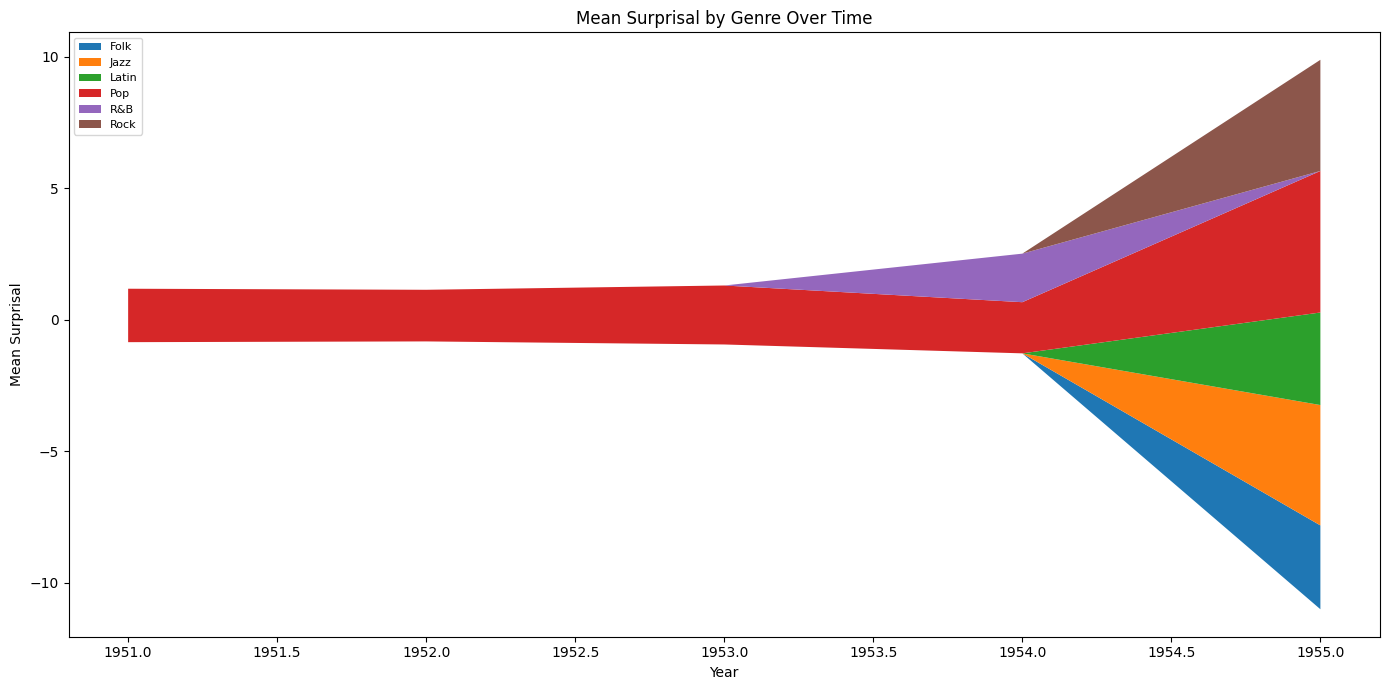

In [103]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- Step 1: Extract year and aggregate by year + genre ---
merged_df["year"] = merged_df["year_position"].str[:4].astype(int)

yearly_genre = (
    merged_df.groupby(["year", "Genre (Broad 1)"])["mean_surprisal"]
    .mean()
    .reset_index()
)

# Pivot so genres are columns, years are rows
pivot_df = yearly_genre.pivot(index="year", columns="Genre (Broad 1)", values="mean_surprisal").fillna(0)

# --- Step 2: Plot streamgraph ---
years = pivot_df.index.values
genres = pivot_df.columns.tolist()
values = pivot_df.values.T  # shape: (n_genres, n_years)

fig, ax = plt.subplots(figsize=(14, 7))

ax.stackplot(years, values, labels=genres, baseline="wiggle")  # "wiggle" gives the stream shape

ax.legend(loc="upper left", fontsize=8)
ax.set_title("Mean Surprisal by Genre Over Time")
ax.set_xlabel("Year")
ax.set_ylabel("Mean Surprisal")

plt.tight_layout()
plt.show()

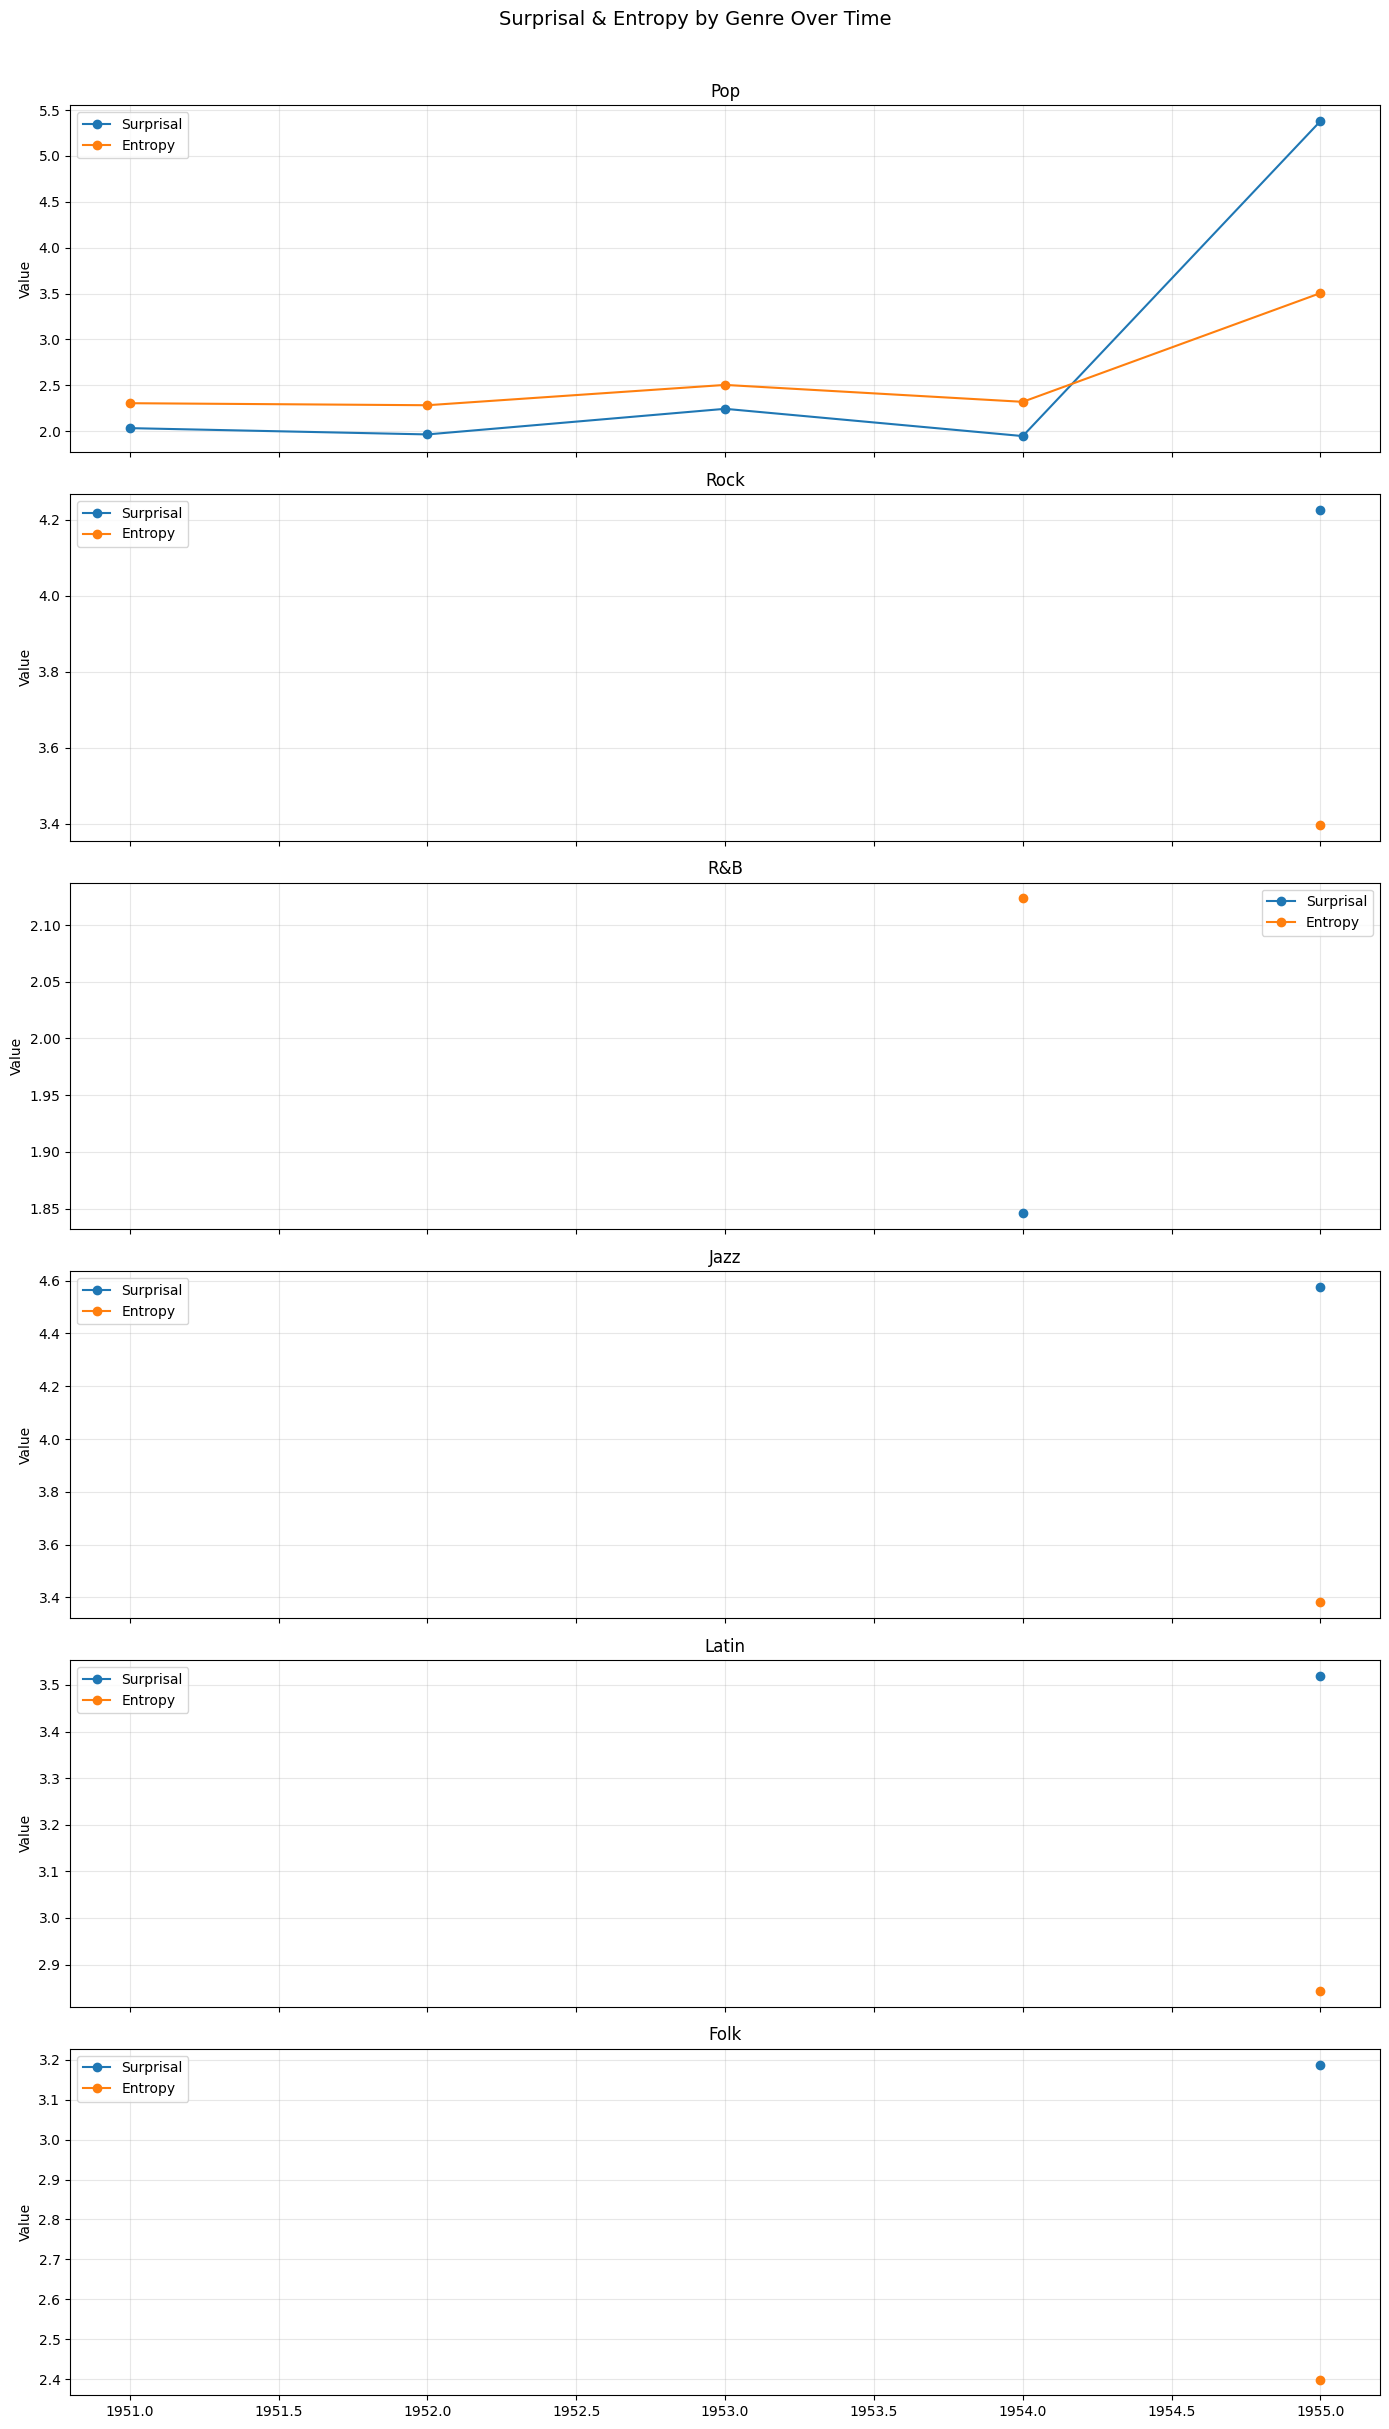

In [104]:
import matplotlib.pyplot as plt

genres = merged_df["Genre (Broad 1)"].dropna().unique()

fig, axes = plt.subplots(len(genres), 1, figsize=(14, 4 * len(genres)), sharex=True)

for ax, genre in zip(axes, genres):
    genre_df = merged_df[merged_df["Genre (Broad 1)"] == genre].copy()
    yearly = (
        genre_df.groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )

    ax.plot(yearly["year"], yearly["mean_surprisal"], label="Surprisal", marker="o")
    ax.plot(yearly["year"], yearly["mean_entropy"], label="Entropy", marker="o")
    ax.set_title(genre)
    ax.set_ylabel("Value")
    # ax.set_xlabel("Year")
    ax.legend()
    ax.grid(True, alpha=0.3)

# axes[-1].set_xlabel("Year")
plt.suptitle("Surprisal & Entropy by Genre Over Time", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Explore all 5 yr lookback files

In [105]:

import re 

five_yr_lookback = []

for start_year in range(1950, 2020):  
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"out/{folder_start}-{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy
        })

    song_df = pd.DataFrame(song_stats)
    # merged_df = pd.merge(song_df, genre_subset, on="year_position", how= "left")

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    five_yr_lookback.append(yearly_stats.iloc[-1])
    
five_yr_lookback = pd.DataFrame(five_yr_lookback)
five_yr_lookback
    

,year,mean_surprisal,mean_entropy
4,1955.0,4.140432,3.094362
4,1956.0,5.107264,3.549987
4,1957.0,9.522592,3.398589
4,1958.0,4.795288,3.225394
4,1959.0,4.682121,3.499601
...,...,...,...
4,2020.0,3.911545,2.721305
4,2021.0,3.366579,2.513096
4,2022.0,3.521129,2.503355
4,2023.0,3.661760,2.769175


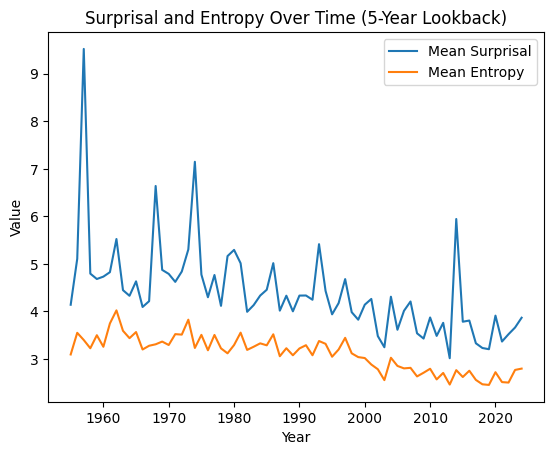

In [106]:
plt.figure()

plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(five_yr_lookback["year"], five_yr_lookback["mean_entropy"], label="Mean Entropy")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Surprisal and Entropy Over Time (5-Year Lookback)")
plt.legend()

plt.show()

In [107]:
five_yr_lookback.sort_values(by='mean_surprisal', ascending=False)

,year,mean_surprisal,mean_entropy
4,1957.0,9.522592,3.398589
4,1974.0,7.148256,3.231644
4,1968.0,6.639194,3.308436
4,2014.0,5.944450,2.764640
4,1962.0,5.522984,4.022275
...,...,...,...
4,2017.0,3.329968,2.559475
4,2003.0,3.246316,2.554681
4,2018.0,3.230632,2.466820
4,2019.0,3.205090,2.453776


In [113]:
import re
import pickle
import numpy as np
import pandas as pd

all_songs_5yr_lookback = []

for start_year in range(1950, 2020):
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"out/{folder_start}-{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)

    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    # Filter columns to only songs from folder_end year before computing stats
    folder_end_cols = [col for col in df.columns if re.split('_', col)[0] == str(folder_end)]

    song_stats = []

    for song_segment in folder_end_cols:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])
        song_id = song_segment_split[1]
        year_position = str(year) + "_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]

        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)

        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy,
            "lookback_window": f"{start_year}-{end_year}"
        })

    all_songs_5yr_lookback.extend(song_stats)

# Combine all windows into one dataframe
all_songs_5yr_lookback = pd.DataFrame(all_songs_5yr_lookback)

# Merge with genre data on shared key
all_songs_5yr_lookback = pd.merge(
    all_songs_5yr_lookback,
    genre_subset,
    on="year_position",
    how="left"
)

# print(all_songs_5yr_lookback.shape)
# all_songs_5yr_lookback

In [112]:
# Looking for outlier years
print(all_songs_5yr_lookback.sort_values(by='mean_surprisal', ascending=False).head())

             song  year year_position  mean_surprisal  mean_entropy  \
912  2014_02_misc  2014       2014_02       40.064836      3.021959   
263     1974_03_1  1974       1974_03       36.879334      4.129195   
172     1968_02_2  1968       1968_02       29.058200      4.123990   
27      1957_05_2  1957       1957_05       22.469586      2.798507   
26      1957_05_3  1957       1957_05       20.644151      3.637532   

    lookback_window Genre (Broad 1) Genre (Broad 2) Genre (Specific 1)  \
912       2009-2013         Hip-hop             Pop               Trap   
263       1969-1973       Funk/Soul             NaN        Philly soul   
172       1963-1967             Pop             NaN     Easy listening   
27        1952-1956            Jazz             NaN           Big band   
26        1952-1956            Jazz             NaN           Big band   

    Genre (Specific 2) Genre (Specific 3)  
912         Electropop            Pop rap  
263                NaN                Na

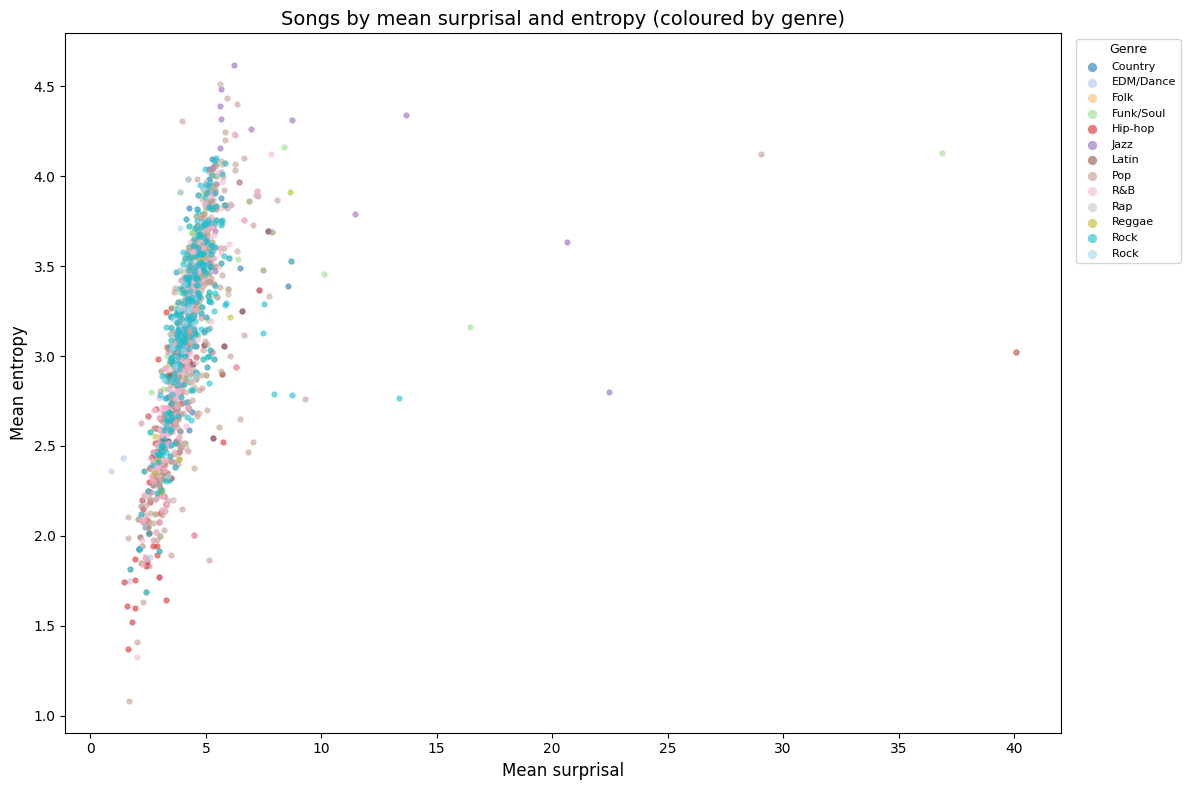

In [110]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = all_songs_5yr_lookback.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()

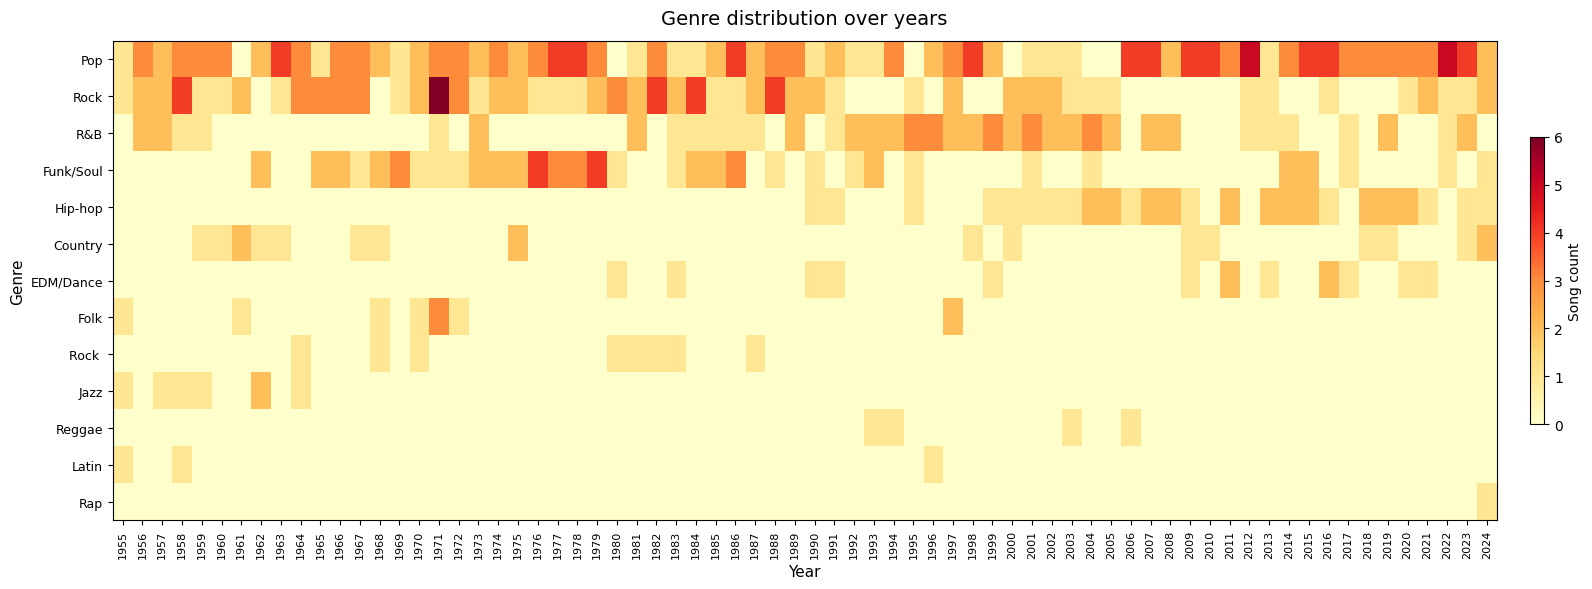

Saved to genre_heatmap.png


In [111]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format, drop NaN genres
df_long = all_songs_5yr_lookback.melt(
    id_vars=["year_position", "year"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Count songs per genre per year (deduplicate same song counted twice
# for the same genre via different columns)
df_long = df_long.drop_duplicates(subset=["year_position", "genre"])
heatmap_data = (
    df_long.groupby(["genre", "year"])
    .size()
    .reset_index(name="count")
)

# Pivot to genre x year matrix
pivot = heatmap_data.pivot(index="genre", columns="year", values="count").fillna(0)

# Sort genres by total count descending so busiest genres are at the top
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, max(6, len(pivot) * 0.45)))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest"
)

# Axes labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Song count", fontsize=10)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Genre", fontsize=11)
ax.set_title("Genre distribution over years", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

### to do: 
Done:
- cluster with y axis suprrisal , x axis entropy, 
- surprisal as a proxy for similarity (how surprising is rock to pop and vice versa)

- genre role it plays in the outliers / distribution per year 

# 3) Replicate all of this for TAR Dataset 

In [115]:
! python3 run_eras_idyom.py -d tar_midis_by_5yr_window -r out/TAR/

Found 74 window folders in 'tar_midis_by_5yr_window'.
No models directory found at 'models' — nothing to clean.

Creating working directories...

Starting IDyOM sliding-window evaluation...

Pair 1: train=1950-1954  |  eval=1951-1955  |  new songs year=1955
----------------------------------------------------
   Copied 10 MIDI file(s) for year 1955 → .TEMP/eval_1955
Viewpoints to use: ['pitch', 'length']
Training ...

________ We are working on 'tar_midis_by_5yr_window/1950-1954'

_____ Filling the database ...

 - tar_midis_by_5yr_window/1950-1954/1952_05_2.mid
 - tar_midis_by_5yr_window/1950-1954/1953_05_2.mid
 - tar_midis_by_5yr_window/1950-1954/1954_02_1.mid
 - tar_midis_by_5yr_window/1950-1954/1953_05_1.mid
 - tar_midis_by_5yr_window/1950-1954/1952_05_1.mid
 - tar_midis_by_5yr_window/1950-1954/1954_02_2.mid
 - tar_midis_by_5yr_window/1950-1954/1953_01_1.mid
 - tar_midis_by_5yr_window/1950-1954/1952_01_1.mid
 - tar_midis_by_5yr_window/1950-1954/1954_04_1.mid
 - tar_midis_by_5yr_win

In [118]:
import re 

tar_five_yr_lookback = []

for start_year in range(1950, 2019):  
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"out/eval_{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)
        
    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    song_stats = []

    for song_segment in df.columns:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])  
        song_id = song_segment_split[1]
        segment_id = song_segment_split[0]
        year_position = str(year) +"_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]
        
        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)
        
        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy
        })

    song_df = pd.DataFrame(song_stats)
    # merged_df = pd.merge(song_df, genre_subset, on="year_position", how= "left")

    # --- Step 2: Aggregate by year ---
    yearly_stats = (
        song_df
        .groupby("year")[["mean_surprisal", "mean_entropy"]]
        .mean()
        .reset_index()
        .sort_values("year")
    )
    
    tar_five_yr_lookback.append(yearly_stats.iloc[-1])
    
tar_five_yr_lookback = pd.DataFrame(tar_five_yr_lookback)
tar_five_yr_lookback
    

,year,mean_surprisal,mean_entropy
0,1955.0,3.924093,3.063419
0,1956.0,5.394582,3.577360
0,1957.0,5.307574,3.572587
0,1958.0,4.323287,3.316282
0,1959.0,4.903602,3.616289
...,...,...,...
0,2019.0,3.193398,2.436591
0,2020.0,4.005865,2.771647
0,2021.0,3.368045,2.514275
0,2022.0,3.530256,2.507051


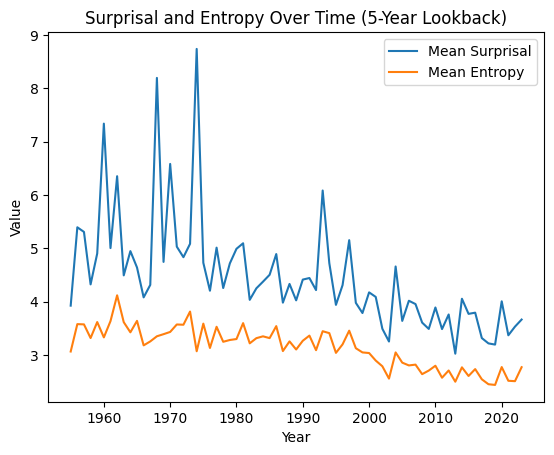

In [119]:
plt.figure()

plt.plot(tar_five_yr_lookback["year"], tar_five_yr_lookback["mean_surprisal"], label="Mean Surprisal")
plt.plot(tar_five_yr_lookback["year"], tar_five_yr_lookback["mean_entropy"], label="Mean Entropy")

plt.xlabel("Year")
plt.ylabel("Value")
plt.title("Surprisal and Entropy Over Time (5-Year Lookback)")
plt.legend()

plt.show()

In [122]:
import re
import pickle
import numpy as np
import pandas as pd

tar_all_songs_5yr_lookback = []

for start_year in range(1950, 2019):
    end_year = start_year + 4
    folder_start = start_year + 1
    folder_end = end_year + 1

    filepath = (
        f"out/eval_{folder_end}/surprises/"
        f"{start_year}-{end_year}/data/"
        f"{start_year}-{end_year}_quantization_24_maxOrder_20_viewpoints_pitch_length.pickle"
    )

    with open(filepath, "rb") as f:
        data = pickle.load(f)

    df = pd.DataFrame(data)
    df = df.drop(columns=["info"])

    # Filter columns to only songs from folder_end year before computing stats
    folder_end_cols = [col for col in df.columns if re.split('_', col)[0] == str(folder_end)]

    song_stats = []

    for song_segment in folder_end_cols:
        song_segment_split = re.split('_', song_segment)
        year = int(song_segment_split[0])
        song_id = song_segment_split[1]
        year_position = str(year) + "_" + song_id
        surprisal_vector = df.loc[0, song_segment]
        entropy_vector = df.loc[1, song_segment]

        mean_surprisal = np.mean(surprisal_vector)
        mean_entropy = np.mean(entropy_vector)

        song_stats.append({
            "song": song_segment,
            "year": year,
            "year_position": year_position,
            "mean_surprisal": mean_surprisal,
            "mean_entropy": mean_entropy,
            "lookback_window": f"{start_year}-{end_year}"
        })

    tar_all_songs_5yr_lookback.extend(song_stats)

# Combine all windows into one dataframe
tar_all_songs_5yr_lookback = pd.DataFrame(tar_all_songs_5yr_lookback)

# Merge with genre data on shared key
tar_all_songs_5yr_lookback = pd.merge(
    tar_all_songs_5yr_lookback,
    genre_subset,
    on="year_position",
    how="left"
)

In [124]:
# Looking for outlier years
print(tar_all_songs_5yr_lookback.sort_values(by='mean_surprisal', ascending=False).head())
# Looking for outlier years
print(all_songs_5yr_lookback.sort_values(by='mean_surprisal', ascending=False).head())

          song  year year_position  mean_surprisal  mean_entropy  \
168  1968_02_2  1968       1968_02       52.000000      4.246207   
260  1974_03_1  1974       1974_03       37.483480      4.035170   
264  1974_03_4  1974       1974_03       36.687670      1.956311   
73   1960_01_1  1960       1960_01       18.848341      2.788569   
69   1960_01_3  1960       1960_01       17.482317      3.806308   

    lookback_window Genre (Broad 1) Genre (Broad 2) Genre (Specific 1)  \
168       1963-1967             Pop             NaN     Easy listening   
260       1969-1973       Funk/Soul             NaN        Philly soul   
264       1969-1973       Funk/Soul             NaN        Philly soul   
73        1955-1959             Pop             NaN     Easy listening   
69        1955-1959             Pop             NaN     Easy listening   

    Genre (Specific 2) Genre (Specific 3)  
168                NaN                NaN  
260                NaN                NaN  
264           

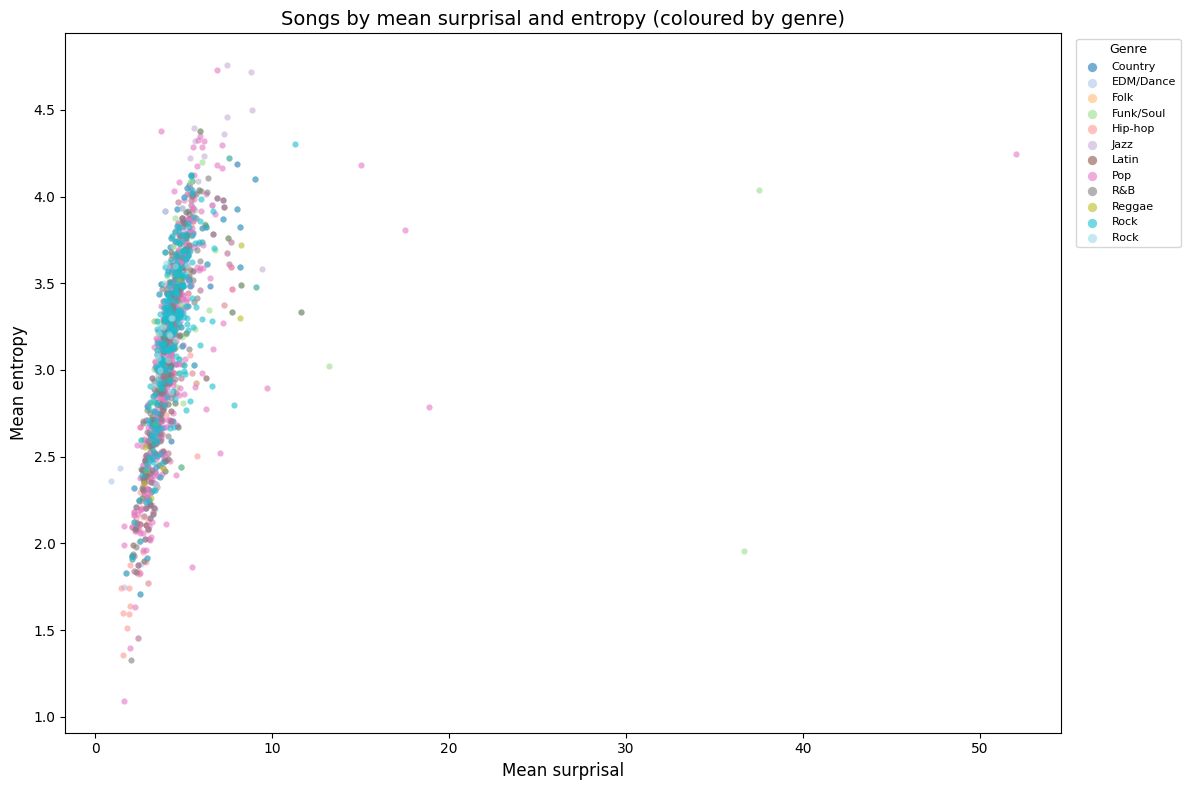

In [125]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format so each song-genre pair is one row, drop NaN genres
df_long = tar_all_songs_5yr_lookback.melt(
    id_vars=["year_position", "mean_surprisal", "mean_entropy"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Get sorted unique genres and assign a color to each
unique_genres = sorted(df_long["genre"].unique())
cmap = plt.get_cmap("tab20", len(unique_genres))
genre_color = {genre: cmap(i) for i, genre in enumerate(unique_genres)}

fig, ax = plt.subplots(figsize=(12, 8))

# Plot each genre as its own layer so legend is clean
for genre in unique_genres:
    subset = df_long[df_long["genre"] == genre]
    ax.scatter(
        subset["mean_surprisal"],
        subset["mean_entropy"],
        color=genre_color[genre],
        label=genre,
        alpha=0.6,
        s=20,
        linewidths=0
    )

ax.set_xlabel("Mean surprisal", fontsize=12)
ax.set_ylabel("Mean entropy", fontsize=12)
ax.set_title("Songs by mean surprisal and entropy (coloured by genre)", fontsize=14)

legend = ax.legend(
    title="Genre",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    fontsize=8,
    title_fontsize=9,
    frameon=True,
    markerscale=1.5
)

plt.tight_layout()
plt.show()

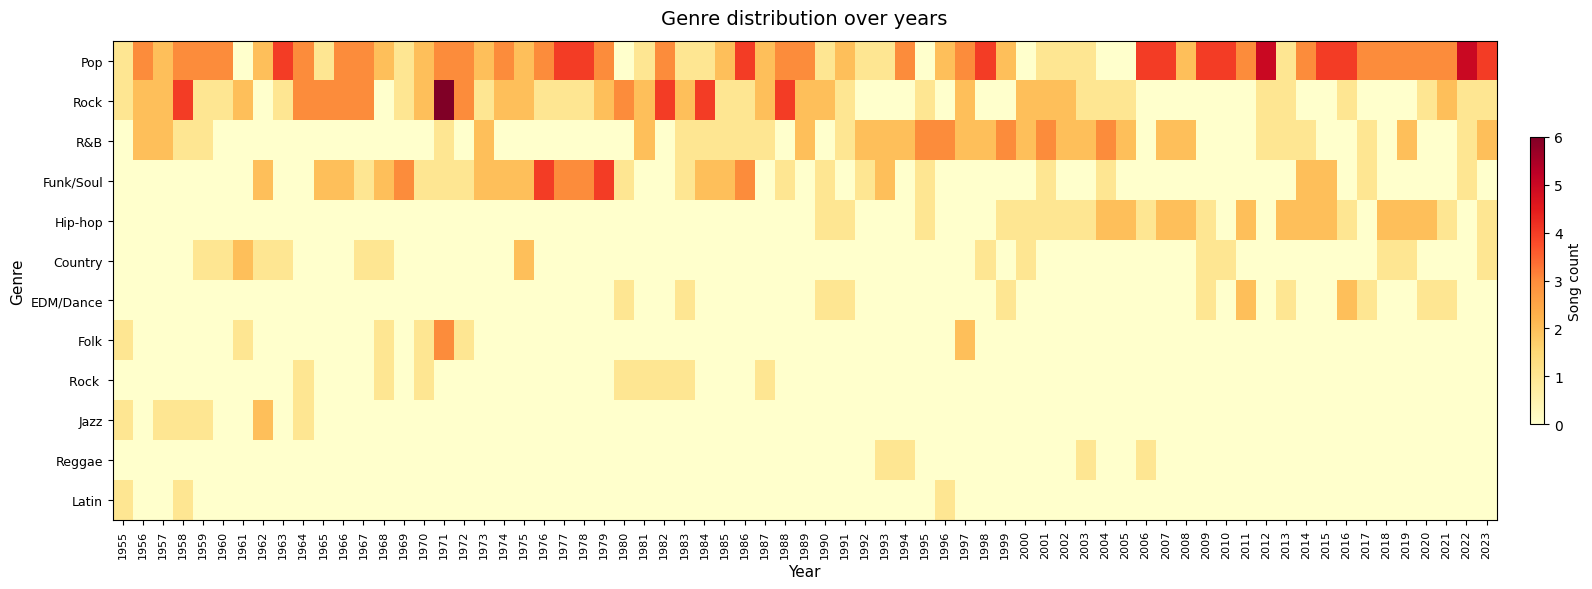

In [127]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

genre_cols = [
    "Genre (Broad 1)", "Genre (Broad 2)",
    # "Genre (Specific 1)", "Genre (Specific 2)", "Genre (Specific 3)"
]

# Melt to long format, drop NaN genres
df_long = tar_all_songs_5yr_lookback.melt(
    id_vars=["year_position", "year"],
    value_vars=genre_cols,
    var_name="genre_col",
    value_name="genre"
).dropna(subset=["genre"])

# Count songs per genre per year (deduplicate same song counted twice
# for the same genre via different columns)
df_long = df_long.drop_duplicates(subset=["year_position", "genre"])
heatmap_data = (
    df_long.groupby(["genre", "year"])
    .size()
    .reset_index(name="count")
)

# Pivot to genre x year matrix
pivot = heatmap_data.pivot(index="genre", columns="year", values="count").fillna(0)

# Sort genres by total count descending so busiest genres are at the top
pivot = pivot.loc[pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(18, max(6, len(pivot) * 0.45)))

im = ax.imshow(
    pivot.values,
    aspect="auto",
    cmap="YlOrRd",
    interpolation="nearest"
)

# Axes labels
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=90, fontsize=8)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)

# Colorbar
cbar = fig.colorbar(im, ax=ax, shrink=0.6, pad=0.02)
cbar.set_label("Song count", fontsize=10)

ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Genre", fontsize=11)
ax.set_title("Genre distribution over years", fontsize=14, pad=12)

plt.tight_layout()
plt.show()

In [130]:
non_idyom_features = pd.read_csv('TAR/output_data/features/non_idyom_features.csv')
non_idyom_features.rename(columns={'ID': 'song'}, inplace=True)
non_idyom_features

,song,Year,Tonal_S,Pitch_SD,MIS,Onset_Density,TI_OD,ISO
0,2018_04_1,2018,0.645476,2.275355,2.360000,2.481031,5.666667,0.795918
1,2019_04_1,2019,0.767247,2.388863,1.491525,2.204609,3.750000,0.448276
2,2012_02_4,2012,0.843972,3.263444,2.086957,2.852988,5.222222,0.666667
3,2005_04_4,2005,0.767572,2.192851,2.354839,1.953062,3.555556,0.233333
4,2004_04_4,2004,0.586094,2.047047,1.755102,2.477022,6.250000,0.520833
...,...,...,...,...,...,...,...,...
1147,1987_01_3,1987,0.797521,2.236068,3.000000,2.616566,3.000000,0.250000
1148,1997_02b_3,1997,0.765530,2.139123,1.800000,2.259427,5.125000,0.333333
1149,1950_04_1,1950,0.641876,3.302833,1.813953,1.807387,5.437500,0.117647
1150,1951_04_1,1951,0.712415,2.547985,1.653846,3.367250,4.388889,0.571429


In [132]:
tar_merged_df = pd.merge(tar_all_songs_5yr_lookback, non_idyom_features, on="song", how="left")
tar_merged_df = tar_merged_df.drop(columns=["Year"])
tar_merged_df

,song,year,year_position,mean_surprisal,mean_entropy,lookback_window,Genre (Broad 1),Genre (Broad 2),Genre (Specific 1),Genre (Specific 2),Genre (Specific 3),Tonal_S,Pitch_SD,MIS,Onset_Density,TI_OD,ISO
0,1955_02_1,1955,1955_02,3.852913,3.059907,1950-1954,Rock,NaN,Rockabilly,NaN,NaN,0.835019,2.686274,2.729730,2.509272,3.454545,0.750000
1,1955_04_1,1955,1955_04,3.539064,2.666113,1950-1954,Jazz,NaN,NaN,NaN,NaN,0.735976,3.535534,4.064516,0.899999,2.000000,0.533333
2,1955_04_2,1955,1955_04,5.335200,4.221983,1950-1954,Jazz,NaN,NaN,NaN,NaN,0.707071,6.254566,2.342857,1.012499,2.400000,0.323529
3,1955_01_1,1955,1955_01,4.670782,3.653806,1950-1954,Latin,NaN,NaN,NaN,NaN,0.803583,3.444694,2.212121,1.874748,3.777778,0.468750
4,1955_01_2,1955,1955_01,2.533620,2.113083,1950-1954,Latin,NaN,NaN,NaN,NaN,0.713279,2.806568,0.692308,3.207177,6.625000,0.725490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1083,2023_04_1,2023,2023_04,3.410491,2.413919,2018-2022,Pop,NaN,Synth-pop,Pop-rock,NaN,0.783898,2.987687,1.466667,2.570090,5.750000,0.295455
1084,2023_02_3,2023,2023_02,4.478731,3.151017,2018-2022,Pop,Rock,Pop-rock,Disco-pop,Nu-disco,0.711530,2.741776,2.050000,2.072931,4.066667,0.508475
1085,2023_04_4,2023,2023_04,4.405248,2.929639,2018-2022,Pop,NaN,Synth-pop,Pop-rock,NaN,0.738655,4.703308,1.424242,1.898812,4.857143,0.406250
1086,2023_02_2,2023,2023_02,3.880537,3.014283,2018-2022,Pop,Rock,Pop-rock,Disco-pop,Nu-disco,0.701370,1.832860,1.913043,2.789115,6.000000,0.363636
